# Manutenção Preditiva em Redutores Planetários por Análise de Vibração
## Análise multicondição com os datasets 1500 rpm / 10 Nm e 2700 rpm / 25 Nm


## 1. Configuração do Experimento Multicondição


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from IPython.display import display
import shap
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = PROJECT_ROOT / "images"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
ENV_FILE = PROJECT_ROOT / ".env"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"IMAGES_DIR: {IMAGES_DIR}")


PROJECT_ROOT: C:\Users\MrTatsch\Documents\trabalho_final_residencia
DATA_DIR: C:\Users\MrTatsch\Documents\trabalho_final_residencia\data
IMAGES_DIR: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images


## 2. Definição dos Datasets e Metadados


In [3]:
fs = 10000
pontos_por_linha = 200
duracao_linha_s = pontos_por_linha / fs
pasta_dados = DATA_DIR

configuracoes_datasets = {
    "1500_10": {
        "arquivo_sufixo": "1500_10",
        "rotacao_entrada_rpm": 1500.0,
        "torque_nm": 10.0,
    },
    "2700_25": {
        "arquivo_sufixo": "2700_25",
        "rotacao_entrada_rpm": 2700.0,
        "torque_nm": 25.0,
    },
}

mapa_classes = {
    0: "Normal",
    1: "Desgaste Superficial",
    2: "Dente Trincado",
    3: "Dente Lascado",
    4: "Dente Ausente",
}

nomes_classes_ordenados = [mapa_classes[i] for i in sorted(mapa_classes)]
labels_classes_curtas = [f"Classe {i}" for i in sorted(mapa_classes)]

def rotulo_classe(classe):
    return f"{classe} - {mapa_classes.get(int(classe), 'Classe desconhecida')}"

for nome_dataset, config in configuracoes_datasets.items():
    for prefixo in ["x", "y", "z", "gt"]:
        caminho_arquivo = pasta_dados / f"{prefixo}_{config['arquivo_sufixo']}.npy"
        if not caminho_arquivo.exists():
            raise FileNotFoundError(f"Arquivo não encontrado: {caminho_arquivo}")

resumo_configuracoes = pd.DataFrame([
    {
        "dataset_operacao": nome_dataset,
        "arquivo_sufixo": config["arquivo_sufixo"],
        "rpm": config["rotacao_entrada_rpm"],
        "torque_nm": config["torque_nm"],
    }
    for nome_dataset, config in configuracoes_datasets.items()
])

display(resumo_configuracoes)


,dataset_operacao,arquivo_sufixo,rpm,torque_nm
0,1500_10,1500_10,1500.0,10.0
1,2700_25,2700_25,2700.0,25.0


## 3. Carregamento dos Dados


In [4]:
def carregar_dataset_operacao(nome_dataset, config):
    vibracao_eixo_x = np.load(pasta_dados / f"x_{config['arquivo_sufixo']}.npy")
    vibracao_eixo_y = np.load(pasta_dados / f"y_{config['arquivo_sufixo']}.npy")
    vibracao_eixo_z = np.load(pasta_dados / f"z_{config['arquivo_sufixo']}.npy")
    gt = np.load(pasta_dados / f"gt_{config['arquivo_sufixo']}.npy").astype(int)

    if not (len(vibracao_eixo_x) == len(vibracao_eixo_y) == len(vibracao_eixo_z) == len(gt)):
        raise ValueError(f"Inconsistência de tamanho no dataset {nome_dataset}.")

    df_vibracao_eixo_x = pd.DataFrame(vibracao_eixo_x)
    df_vibracao_eixo_y = pd.DataFrame(vibracao_eixo_y)
    df_vibracao_eixo_z = pd.DataFrame(vibracao_eixo_z)

    df_vibracao_eixo_x["classe"] = gt
    df_vibracao_eixo_y["classe"] = gt
    df_vibracao_eixo_z["classe"] = gt

    return {
        "dataset_operacao": nome_dataset,
        "arquivo_sufixo": config["arquivo_sufixo"],
        "rpm": float(config["rotacao_entrada_rpm"]),
        "torque_nm": float(config["torque_nm"]),
        "condicao_operacao": f"{int(config['rotacao_entrada_rpm'])} rpm / {int(config['torque_nm'])} Nm",
        "df_por_eixo": {
            "x": df_vibracao_eixo_x,
            "y": df_vibracao_eixo_y,
            "z": df_vibracao_eixo_z,
        },
        "gt": gt,
    }

datasets_brutos = {
    nome_dataset: carregar_dataset_operacao(nome_dataset, config)
    for nome_dataset, config in configuracoes_datasets.items()
}

resumo_datasets_brutos = []
for nome_dataset, info in datasets_brutos.items():
    resumo_datasets_brutos.append({
        "dataset_operacao": nome_dataset,
        "condicao_operacao": info["condicao_operacao"],
        "linhas": int(info["df_por_eixo"]["x"].shape[0]),
        "colunas_sinal": int(info["df_por_eixo"]["x"].shape[1] - 1),
        "classes_unicas": sorted(np.unique(info["gt"]).astype(int).tolist()),
    })

resumo_datasets_brutos = pd.DataFrame(resumo_datasets_brutos)
display(resumo_datasets_brutos)

,dataset_operacao,condicao_operacao,linhas,colunas_sinal,classes_unicas
0,1500_10,1500 rpm / 10 Nm,50000,200,"[0, 1, 2, 3, 4]"
1,2700_25,2700 rpm / 25 Nm,50000,200,"[0, 1, 2, 3, 4]"


## 4. Segmentação do Sinal por Condição


In [5]:
duracao_intervalo_s = 1.0
linhas_por_intervalo = int(duracao_intervalo_s / duracao_linha_s)
amostras_por_intervalo = linhas_por_intervalo * pontos_por_linha

def segmentar_dataset_por_condicao(dataset_info):
    segmentos_por_eixo_classe = {}

    for eixo, df_eixo in dataset_info["df_por_eixo"].items():
        segmentos_por_eixo_classe[eixo] = {}

        for classe in sorted(mapa_classes):
            matriz_classe = df_eixo[df_eixo["classe"] == classe].drop(columns="classe").to_numpy()
            if matriz_classe.size == 0:
                segmentos = np.empty((0, amostras_por_intervalo))
            else:
                if matriz_classe.size % amostras_por_intervalo != 0:
                    raise ValueError(
                        f"O total de amostras da classe {classe} no eixo {eixo} não é múltiplo de {amostras_por_intervalo}."
                    )
                segmentos = matriz_classe.reshape(-1, amostras_por_intervalo)

            segmentos_por_eixo_classe[eixo][classe] = segmentos

    return segmentos_por_eixo_classe

datasets_processados = {}
resumo_segmentacao = []

for nome_dataset, info in datasets_brutos.items():
    info_processado = dict(info)
    info_processado["segmentos_por_eixo_classe"] = segmentar_dataset_por_condicao(info)
    datasets_processados[nome_dataset] = info_processado

    for classe in sorted(mapa_classes):
        resumo_segmentacao.append({
            "dataset_operacao": nome_dataset,
            "condicao_operacao": info["condicao_operacao"],
            "classe": classe,
            "classe_nome": mapa_classes[classe],
            "segmentos_por_classe": int(info_processado["segmentos_por_eixo_classe"]["x"][classe].shape[0]),
        })

print(f"Duração do intervalo: {duracao_intervalo_s:.2f} s")
print(f"Linhas por intervalo: {linhas_por_intervalo}")
print(f"Amostras por intervalo: {amostras_por_intervalo}")

resumo_segmentacao = pd.DataFrame(resumo_segmentacao)
display(resumo_segmentacao)


Duração do intervalo: 1.00 s
Linhas por intervalo: 50
Amostras por intervalo: 10000


,dataset_operacao,condicao_operacao,classe,classe_nome,segmentos_por_classe
0,1500_10,1500 rpm / 10 Nm,0,Normal,200
1,1500_10,1500 rpm / 10 Nm,1,Desgaste Superficial,200
2,1500_10,1500 rpm / 10 Nm,2,Dente Trincado,200
3,1500_10,1500 rpm / 10 Nm,3,Dente Lascado,200
4,1500_10,1500 rpm / 10 Nm,4,Dente Ausente,200
5,2700_25,2700 rpm / 25 Nm,0,Normal,200
6,2700_25,2700 rpm / 25 Nm,1,Desgaste Superficial,200
7,2700_25,2700 rpm / 25 Nm,2,Dente Trincado,200
8,2700_25,2700 rpm / 25 Nm,3,Dente Lascado,200
9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,200


## 5. Parâmetros Cinemáticos por Condição


In [6]:
Zr1 = 100.0
Zs1 = 20.0
Zr2 = 100.0
Zs2 = 28.0
reducao_primeiro_estagio = 6.0

def calcular_parametros_cinematicos(rotacao_entrada_rpm):
    Fsh1 = rotacao_entrada_rpm / 60.0
    Fm1 = ((Zr1 * Zs1) / (Zr1 + Zs1)) * Fsh1
    Fh1 = (Zs1 / (Zr1 + Zs1)) * Fsh1
    Fcsd1 = Fm1 / Zs1
    Fcsl1 = 3 * Fcsd1

    Fsh2 = (rotacao_entrada_rpm / reducao_primeiro_estagio) / 60.0
    Fm2 = ((Zr2 * Zs2) / (Zr2 + Zs2)) * Fsh2
    Fh2 = (Zs2 / (Zr2 + Zs2)) * Fsh2
    Fcsd2 = Fm2 / Zs2
    Fcsl2 = 4 * Fcsd2

    return {
        "Fsh1": Fsh1,
        "Fm1": Fm1,
        "Fh1": Fh1,
        "Fcsd1": Fcsd1,
        "Fcsl1": Fcsl1,
        "Fsh2": Fsh2,
        "Fm2": Fm2,
        "Fh2": Fh2,
        "Fcsd2": Fcsd2,
        "Fcsl2": Fcsl2,
    }

resumo_cinematica = []
for nome_dataset, info in datasets_processados.items():
    parametros = calcular_parametros_cinematicos(info["rpm"])
    info["parametros_cinematicos"] = parametros

    resumo_cinematica.append({
        "dataset_operacao": nome_dataset,
        "condicao_operacao": info["condicao_operacao"],
        "Fm1_hz": parametros["Fm1"],
        "Fm2_hz": parametros["Fm2"],
        "Fh2_hz": parametros["Fh2"],
        "Fcsd2_hz": parametros["Fcsd2"],
        "Fcsl2_hz": parametros["Fcsl2"],
    })

resumo_cinematica = pd.DataFrame(resumo_cinematica)
display(resumo_cinematica)


,dataset_operacao,condicao_operacao,Fm1_hz,Fm2_hz,Fh2_hz,Fcsd2_hz,Fcsl2_hz
0,1500_10,1500 rpm / 10 Nm,416.666667,91.145833,0.911458,3.255208,13.020833
1,2700_25,2700 rpm / 25 Nm,750.000000,164.062500,1.640625,5.859375,23.437500


## 6. Extração de Features por Condição


In [7]:
largura_busca_fm_real_hz = 10.0
largura_banda_harmonica_hz = 10.0
ordens_harmonicas_fm2 = list(range(1, 6))
ordens_harmonicas_fm1 = list(range(1, 6))
janela_hann = np.hanning(amostras_por_intervalo)
frequencias_fft = np.fft.rfftfreq(amostras_por_intervalo, d=1 / fs)

def calcular_espectro_amplitude(sinal_segmento, janela):
    sinal_centrado = sinal_segmento - np.mean(sinal_segmento)
    sinal_janelado = sinal_centrado * janela
    espectro = np.fft.rfft(sinal_janelado)
    amplitude = np.abs(espectro) * 2.0 / janela.sum()
    amplitude[0] = 0.0
    return amplitude

def extrair_pico_na_banda(amplitude_espectral, frequencias, mascara_banda):
    if not np.any(mascara_banda):
        return np.nan, np.nan

    amplitudes_banda = amplitude_espectral[mascara_banda]
    frequencias_banda = frequencias[mascara_banda]
    indice_pico = int(np.argmax(amplitudes_banda))
    return float(amplitudes_banda[indice_pico]), float(frequencias_banda[indice_pico])

def extrair_soma_amplitudes_na_banda(amplitude_espectral, mascara_banda):
    if not np.any(mascara_banda):
        return np.nan
    return float(np.sum(np.square(amplitude_espectral[mascara_banda])))


def extrair_amplitude_maxima_na_banda(amplitude_espectral, mascara_banda):
    if not np.any(mascara_banda):
        return np.nan
    return float(np.max(amplitude_espectral[mascara_banda]))


def calcular_rms(sinal_segmento):
    return float(np.sqrt(np.mean(np.square(sinal_segmento))))


def extrair_features_condicao(nome_dataset, info):
    parametros = info["parametros_cinematicos"]
    segmentos_por_eixo_classe = info["segmentos_por_eixo_classe"]

    mascara_fm2_real = (
        (frequencias_fft >= parametros["Fm2"] - largura_busca_fm_real_hz)
        & (frequencias_fft <= parametros["Fm2"] + largura_busca_fm_real_hz)
    )
    mascara_fm1_real = (
        (frequencias_fft >= parametros["Fm1"] - largura_busca_fm_real_hz)
        & (frequencias_fft <= parametros["Fm1"] + largura_busca_fm_real_hz)
    )

    linhas_features = []

    for classe in sorted(mapa_classes):
        quantidade_segmentos = segmentos_por_eixo_classe["x"][classe].shape[0]

        for segmento_id in range(quantidade_segmentos):
            linha = {
                "dataset_operacao": nome_dataset,
                "condicao_operacao": info["condicao_operacao"],
                "rpm": info["rpm"],
                "torque_nm": info["torque_nm"],
                "classe": classe,
                "segmento_id": segmento_id,
                "tempo_inicial_s": segmento_id * duracao_intervalo_s,
                "tempo_final_s": (segmento_id + 1) * duracao_intervalo_s,
            }

            for eixo in ["x", "y", "z"]:
                sinal_segmento = segmentos_por_eixo_classe[eixo][classe][segmento_id]
                linha[f"rms_{eixo}"] = calcular_rms(sinal_segmento)
                amplitude_espectral = calcular_espectro_amplitude(sinal_segmento, janela_hann)

                _, fm2_real = extrair_pico_na_banda(
                    amplitude_espectral,
                    frequencias_fft,
                    mascara_fm2_real,
                )
                linha[f"fm_real_{eixo}"] = fm2_real

                for ordem_harmonica in ordens_harmonicas_fm2:
                    frequencia_alvo = ordem_harmonica * fm2_real
                    mascara_harmonica = (
                        (frequencias_fft >= frequencia_alvo - largura_banda_harmonica_hz)
                        & (frequencias_fft <= frequencia_alvo + largura_banda_harmonica_hz)
                    )
                    linha[f"amp_fm_h{ordem_harmonica}_{eixo}"] = extrair_soma_amplitudes_na_banda(
                        amplitude_espectral,
                        mascara_harmonica,
                    )
                    linha[f"amp_max_fm_h{ordem_harmonica}_{eixo}"] = extrair_amplitude_maxima_na_banda(
                        amplitude_espectral,
                        mascara_harmonica,
                    )

                _, fm1_real = extrair_pico_na_banda(
                    amplitude_espectral,
                    frequencias_fft,
                    mascara_fm1_real,
                )
                linha[f"fm1_real_{eixo}"] = fm1_real

                for ordem_harmonica in ordens_harmonicas_fm1:
                    frequencia_alvo_fm1 = ordem_harmonica * fm1_real
                    mascara_harmonica_fm1 = (
                        (frequencias_fft >= frequencia_alvo_fm1 - largura_banda_harmonica_hz)
                        & (frequencias_fft <= frequencia_alvo_fm1 + largura_banda_harmonica_hz)
                    )
                    linha[f"amp_fm1_h{ordem_harmonica}_{eixo}"] = extrair_soma_amplitudes_na_banda(
                        amplitude_espectral,
                        mascara_harmonica_fm1,
                    )
                    linha[f"amp_max_fm1_h{ordem_harmonica}_{eixo}"] = extrair_amplitude_maxima_na_banda(
                        amplitude_espectral,
                        mascara_harmonica_fm1,
                    )

            linhas_features.append(linha)

    return pd.DataFrame(linhas_features)

features_por_dataset = {}
resumo_features = []

for nome_dataset, info in datasets_processados.items():
    features_condicao = extrair_features_condicao(nome_dataset, info)
    features_por_dataset[nome_dataset] = features_condicao
    resumo_features.append({
        "dataset_operacao": nome_dataset,
        "condicao_operacao": info["condicao_operacao"],
        "amostras": int(features_condicao.shape[0]),
        "colunas_totais": int(features_condicao.shape[1]),
    })

resumo_features = pd.DataFrame(resumo_features)
display(resumo_features)


,dataset_operacao,condicao_operacao,amostras,colunas_totais
0,1500_10,1500 rpm / 10 Nm,1000,77
1,2700_25,2700 rpm / 25 Nm,1000,77


## 7. Concatenação e Preparação para Modelagem


In [8]:
features_modelo = pd.concat(
    [features_por_dataset[nome_dataset] for nome_dataset in sorted(features_por_dataset)],
    ignore_index=True,
)

colunas_identificacao = [
    "dataset_operacao",
    "condicao_operacao",
    "rpm",
    "torque_nm",
    "classe",
    "segmento_id",
    "tempo_inicial_s",
    "tempo_final_s",
]

colunas_features = [coluna for coluna in features_modelo.columns if coluna not in colunas_identificacao]

X_features = features_modelo[colunas_features].copy()
y_features = features_modelo["classe"].copy()

estrato_modelagem = (
    features_modelo["dataset_operacao"].astype(str)
    + "_classe_"
    + features_modelo["classe"].astype(str)
)

indices_treino, indices_teste = train_test_split(
    features_modelo.index.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=estrato_modelagem,
)

X_train = X_features.loc[indices_treino].copy()
X_test = X_features.loc[indices_teste].copy()
y_train = y_features.loc[indices_treino].copy()
y_test = y_features.loc[indices_teste].copy()

metadados_train = features_modelo.loc[indices_treino, colunas_identificacao].reset_index(drop=True)
metadados_test = features_modelo.loc[indices_teste, colunas_identificacao].reset_index(drop=True)

classes_roc = np.array(sorted(mapa_classes))
y_test_bin = label_binarize(y_test, classes=classes_roc)

resumo_split = pd.concat([
    metadados_train.assign(split="Treino"),
    metadados_test.assign(split="Teste"),
], ignore_index=True)

resumo_split = (
    resumo_split.groupby(["split", "dataset_operacao", "classe"])
    .size()
    .reset_index(name="amostras")
    .sort_values(["split", "dataset_operacao", "classe"])
    .reset_index(drop=True)
)

print(f"Tamanho treino: {X_train.shape}")
print(f"Tamanho teste: {X_test.shape}")
print(f"Tamanho total: {X_features.shape}")

display(resumo_split)
features_modelo.head()


Tamanho treino: (1400, 69)
Tamanho teste: (600, 69)
Tamanho total: (2000, 69)


,split,dataset_operacao,classe,amostras
0,Teste,1500_10,0,60
1,Teste,1500_10,1,60
2,Teste,1500_10,2,60
3,Teste,1500_10,3,60
4,Teste,1500_10,4,60
5,Teste,2700_25,0,60
6,Teste,2700_25,1,60
7,Teste,2700_25,2,60
8,Teste,2700_25,3,60
9,Teste,2700_25,4,60


,dataset_operacao,condicao_operacao,rpm,torque_nm,classe,segmento_id,tempo_inicial_s,tempo_final_s,rms_x,fm_real_x,...,amp_fm1_h1_z,amp_max_fm1_h1_z,amp_fm1_h2_z,amp_max_fm1_h2_z,amp_fm1_h3_z,amp_max_fm1_h3_z,amp_fm1_h4_z,amp_max_fm1_h4_z,amp_fm1_h5_z,amp_max_fm1_h5_z
0,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,0,0.0,1.0,0.093619,97.0,...,0.012601,0.051148,0.003816,0.028411,0.002763,0.019189,0.003938,0.027865,0.001289,0.014621
1,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,1,1.0,2.0,0.092136,86.0,...,0.014745,0.048858,0.003674,0.025203,0.004577,0.026847,0.006790,0.032146,0.001590,0.013768
2,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,2,2.0,3.0,0.092540,82.0,...,0.004880,0.026379,0.004518,0.022676,0.002303,0.023235,0.004474,0.026381,0.001858,0.018686
3,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,3,3.0,4.0,0.094165,82.0,...,0.006851,0.033590,0.003141,0.028348,0.002489,0.022190,0.005438,0.027704,0.001089,0.011812
4,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,4,4.0,5.0,0.093166,86.0,...,0.009822,0.049569,0.005950,0.034627,0.001068,0.011855,0.004915,0.037079,0.000384,0.007346


## 8. Treinamento dos Modelos


In [9]:
def calcular_metricas_multiclasse(nome_modelo, y_true, y_pred):
    return {
        "modelo": nome_modelo,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=1,
)

xgboost_model = XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1,
)

catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    iterations=300,
    depth=6,
    learning_rate=0.05,
    random_seed=42,
    verbose=False,
)

lightgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=5,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    verbosity=-1,
)

modelos = {
    "RandomForest": random_forest,
    "XGBoost": xgboost_model,
    "CatBoost": catboost_model,
    "LightGBM": lightgbm_model,
}

resultados_modelos = {}
metricas_globais = []

for nome_modelo, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = np.asarray(modelo.predict(X_test)).astype(int).ravel()
    y_proba = modelo.predict_proba(X_test)

    resultados_modelos[nome_modelo] = {
        "modelo": modelo,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }
    metricas_globais.append(calcular_metricas_multiclasse(nome_modelo, y_test, y_pred))

comparacao_modelos = pd.DataFrame(metricas_globais).sort_values(
    ["f1_macro", "accuracy"],
    ascending=False,
).reset_index(drop=True)

y_pred_rf = resultados_modelos["RandomForest"]["y_pred"]
y_proba_rf = resultados_modelos["RandomForest"]["y_proba"]
y_pred_xgb = resultados_modelos["XGBoost"]["y_pred"]
y_proba_xgb = resultados_modelos["XGBoost"]["y_proba"]
y_pred_cat = resultados_modelos["CatBoost"]["y_pred"]
y_proba_cat = resultados_modelos["CatBoost"]["y_proba"]
y_pred_lgbm = resultados_modelos["LightGBM"]["y_pred"]
y_proba_lgbm = resultados_modelos["LightGBM"]["y_proba"]

display(comparacao_modelos)


,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,XGBoost,0.973333,0.973345,0.973333,0.973319
1,LightGBM,0.971667,0.971981,0.971667,0.971697
2,RandomForest,0.971667,0.971717,0.971667,0.971658
3,CatBoost,0.966667,0.966715,0.966667,0.966637


## 9. Avaliação Global e por Condição Operacional


In [10]:
def calcular_metricas_por_condicao(nome_modelo, y_true, y_pred, metadados):
    metricas = []

    for dataset_operacao in sorted(metadados["dataset_operacao"].unique()):
        mascara = metadados["dataset_operacao"] == dataset_operacao
        y_true_condicao = y_true.loc[mascara.to_numpy()]
        y_pred_condicao = y_pred[mascara.to_numpy()]
        condicao_operacao = metadados.loc[mascara, "condicao_operacao"].iloc[0]

        linha = calcular_metricas_multiclasse(nome_modelo, y_true_condicao, y_pred_condicao)
        linha["dataset_operacao"] = dataset_operacao
        linha["condicao_operacao"] = condicao_operacao
        linha["amostras_teste"] = int(mascara.sum())
        metricas.append(linha)

    return pd.DataFrame(metricas)

comparacao_modelos_por_condicao = pd.concat([
    calcular_metricas_por_condicao("RandomForest", y_test, y_pred_rf, metadados_test),
    calcular_metricas_por_condicao("XGBoost", y_test, y_pred_xgb, metadados_test),
    calcular_metricas_por_condicao("CatBoost", y_test, y_pred_cat, metadados_test),
    calcular_metricas_por_condicao("LightGBM", y_test, y_pred_lgbm, metadados_test),
], ignore_index=True)

display(comparacao_modelos)
display(comparacao_modelos_por_condicao)


,modelo,accuracy,precision_macro,recall_macro,f1_macro
0,XGBoost,0.973333,0.973345,0.973333,0.973319
1,LightGBM,0.971667,0.971981,0.971667,0.971697
2,RandomForest,0.971667,0.971717,0.971667,0.971658
3,CatBoost,0.966667,0.966715,0.966667,0.966637


,modelo,accuracy,precision_macro,recall_macro,f1_macro,dataset_operacao,condicao_operacao,amostras_teste
0,RandomForest,0.960000,0.960389,0.960000,0.959901,1500_10,1500 rpm / 10 Nm,300
1,RandomForest,0.983333,0.983497,0.983333,0.983332,2700_25,2700 rpm / 25 Nm,300
2,XGBoost,0.963333,0.963695,0.963333,0.963243,1500_10,1500 rpm / 10 Nm,300
3,XGBoost,0.983333,0.983658,0.983333,0.983301,2700_25,2700 rpm / 25 Nm,300
4,CatBoost,0.956667,0.956668,0.956667,0.956373,1500_10,1500 rpm / 10 Nm,300
5,CatBoost,0.976667,0.977143,0.976667,0.976660,2700_25,2700 rpm / 25 Nm,300
6,LightGBM,0.963333,0.964081,0.963333,0.963139,1500_10,1500 rpm / 10 Nm,300
7,LightGBM,0.980000,0.980324,0.980000,0.979968,2700_25,2700 rpm / 25 Nm,300


In [11]:
def plotar_avaliacao_modelo(nome_modelo, y_true, y_pred, y_proba, sufixo_arquivo):
    print(f"Métricas - {nome_modelo}")
    metricas_modelo = comparacao_modelos[comparacao_modelos["modelo"] == nome_modelo]
    print(metricas_modelo.to_string(index=False))
    print(classification_report(
        y_true,
        y_pred,
        labels=sorted(mapa_classes),
        target_names=nomes_classes_ordenados,
        zero_division=0,
    ))

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        ax=axes[0],
        cmap="Blues",
        colorbar=False,
        display_labels=labels_classes_curtas,
    )
    axes[0].set_title(f"Matriz de confusão - {nome_modelo}")

    for indice_classe, classe in enumerate(classes_roc):
        fpr_classe, tpr_classe, _ = roc_curve(y_test_bin[:, indice_classe], y_proba[:, indice_classe])
        auc_classe = auc(fpr_classe, tpr_classe)
        axes[1].plot(
            fpr_classe,
            tpr_classe,
            linewidth=1.5,
            label=f"Classe {classe} (AUC = {auc_classe:.3f})",
        )

    axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[1].set_title(f"Curva ROC - {nome_modelo}")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    pasta_imagens = IMAGES_DIR
    pasta_imagens.mkdir(exist_ok=True)
    caminho_arquivo = pasta_imagens / f"avaliacao_{sufixo_arquivo}_multicondicao.png"
    fig.savefig(caminho_arquivo, dpi=300, bbox_inches="tight")
    print(f"Gráfico salvo em: {caminho_arquivo}")
    plt.show()


Métricas - RandomForest
      modelo  accuracy  precision_macro  recall_macro  f1_macro
RandomForest  0.971667         0.971717      0.971667  0.971658
                      precision    recall  f1-score   support

              Normal       0.98      0.98      0.98       120
Desgaste Superficial       0.99      0.98      0.99       120
      Dente Trincado       0.95      0.97      0.96       120
       Dente Lascado       0.98      0.98      0.98       120
       Dente Ausente       0.96      0.94      0.95       120

            accuracy                           0.97       600
           macro avg       0.97      0.97      0.97       600
        weighted avg       0.97      0.97      0.97       600

Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\avaliacao_randomforest_multicondicao.png


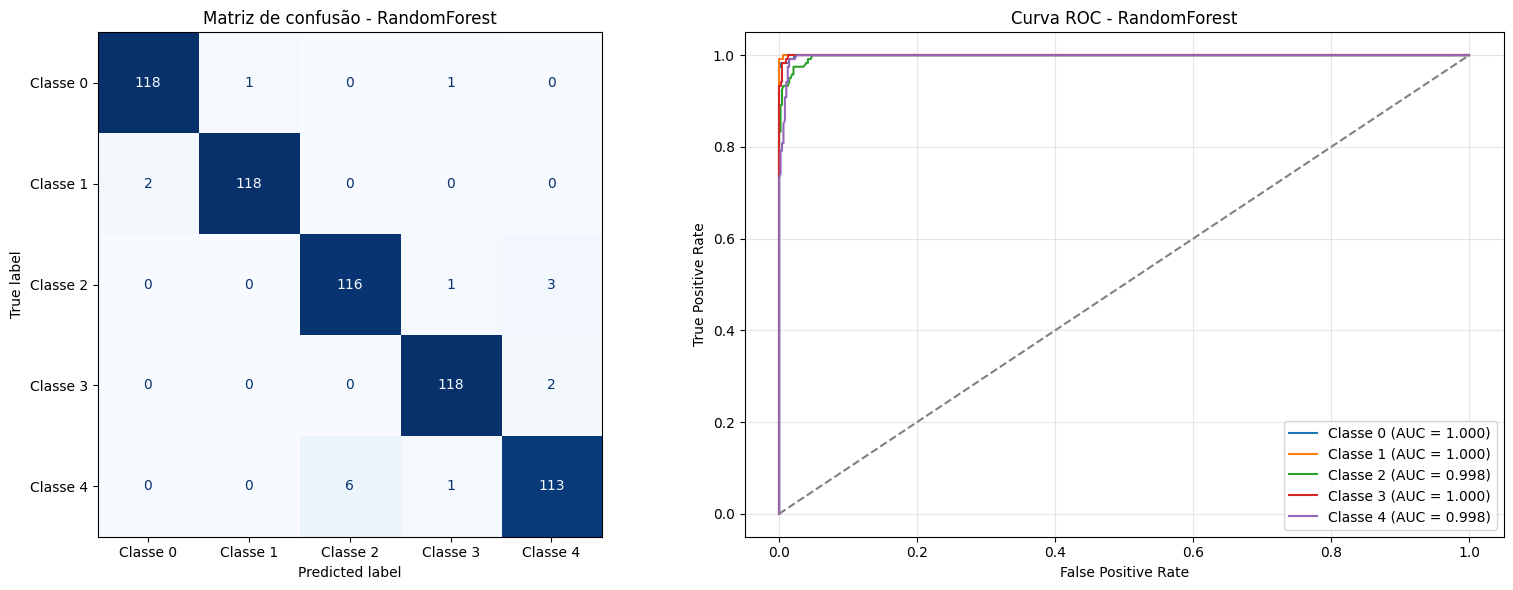

In [12]:
plotar_avaliacao_modelo("RandomForest", y_test, y_pred_rf, y_proba_rf, "randomforest")


Métricas - XGBoost
 modelo  accuracy  precision_macro  recall_macro  f1_macro
XGBoost  0.973333         0.973345      0.973333  0.973319
                      precision    recall  f1-score   support

              Normal       0.97      0.97      0.97       120
Desgaste Superficial       0.98      0.97      0.98       120
      Dente Trincado       0.97      0.97      0.97       120
       Dente Lascado       0.98      0.99      0.98       120
       Dente Ausente       0.96      0.96      0.96       120

            accuracy                           0.97       600
           macro avg       0.97      0.97      0.97       600
        weighted avg       0.97      0.97      0.97       600

Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\avaliacao_xgboost_multicondicao.png


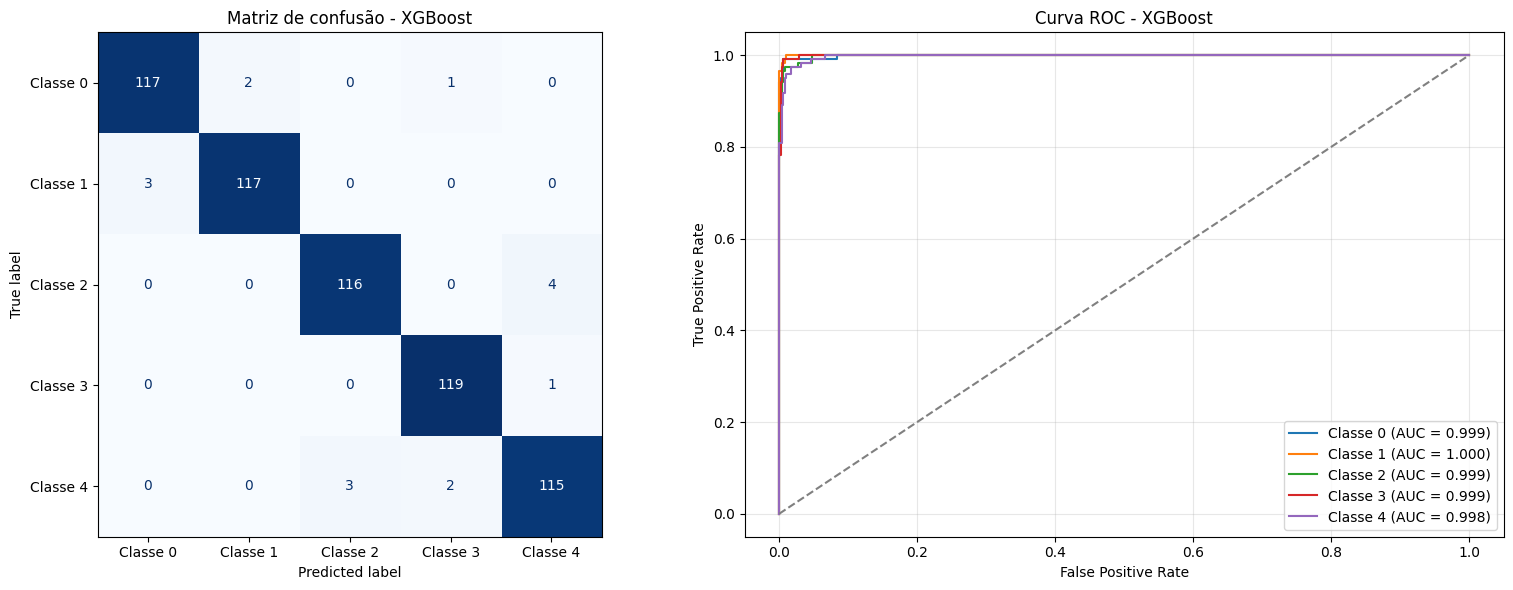

In [13]:
plotar_avaliacao_modelo("XGBoost", y_test, y_pred_xgb, y_proba_xgb, "xgboost")


Métricas - CatBoost
  modelo  accuracy  precision_macro  recall_macro  f1_macro
CatBoost  0.966667         0.966715      0.966667  0.966637
                      precision    recall  f1-score   support

              Normal       0.98      0.97      0.98       120
Desgaste Superficial       0.98      0.98      0.98       120
      Dente Trincado       0.97      0.94      0.95       120
       Dente Lascado       0.97      0.98      0.98       120
       Dente Ausente       0.94      0.95      0.95       120

            accuracy                           0.97       600
           macro avg       0.97      0.97      0.97       600
        weighted avg       0.97      0.97      0.97       600

Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\avaliacao_catboost_multicondicao.png


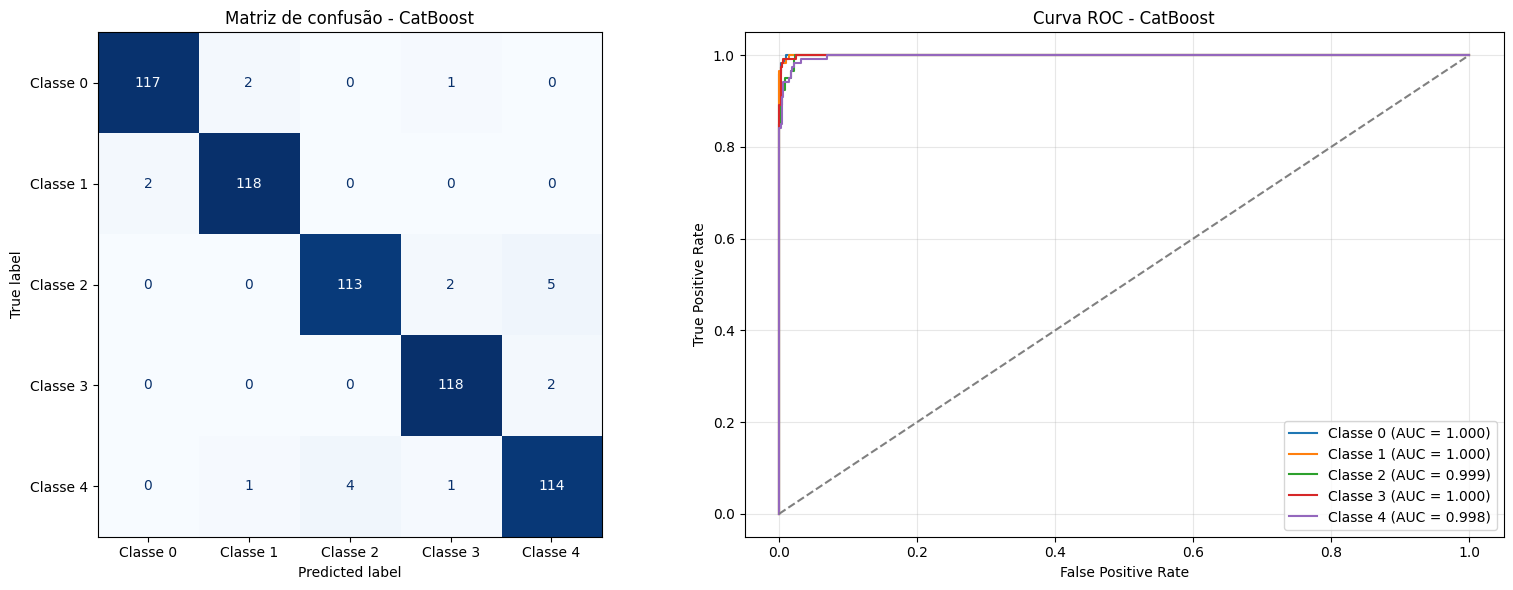

In [14]:
plotar_avaliacao_modelo("CatBoost", y_test, y_pred_cat, y_proba_cat, "catboost")


Métricas - LightGBM
  modelo  accuracy  precision_macro  recall_macro  f1_macro
LightGBM  0.971667         0.971981      0.971667  0.971697
                      precision    recall  f1-score   support

              Normal       0.98      0.97      0.98       120
Desgaste Superficial       0.98      0.97      0.98       120
      Dente Trincado       0.98      0.95      0.97       120
       Dente Lascado       0.97      0.98      0.98       120
       Dente Ausente       0.94      0.97      0.96       120

            accuracy                           0.97       600
           macro avg       0.97      0.97      0.97       600
        weighted avg       0.97      0.97      0.97       600

Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\avaliacao_lightgbm_multicondicao.png


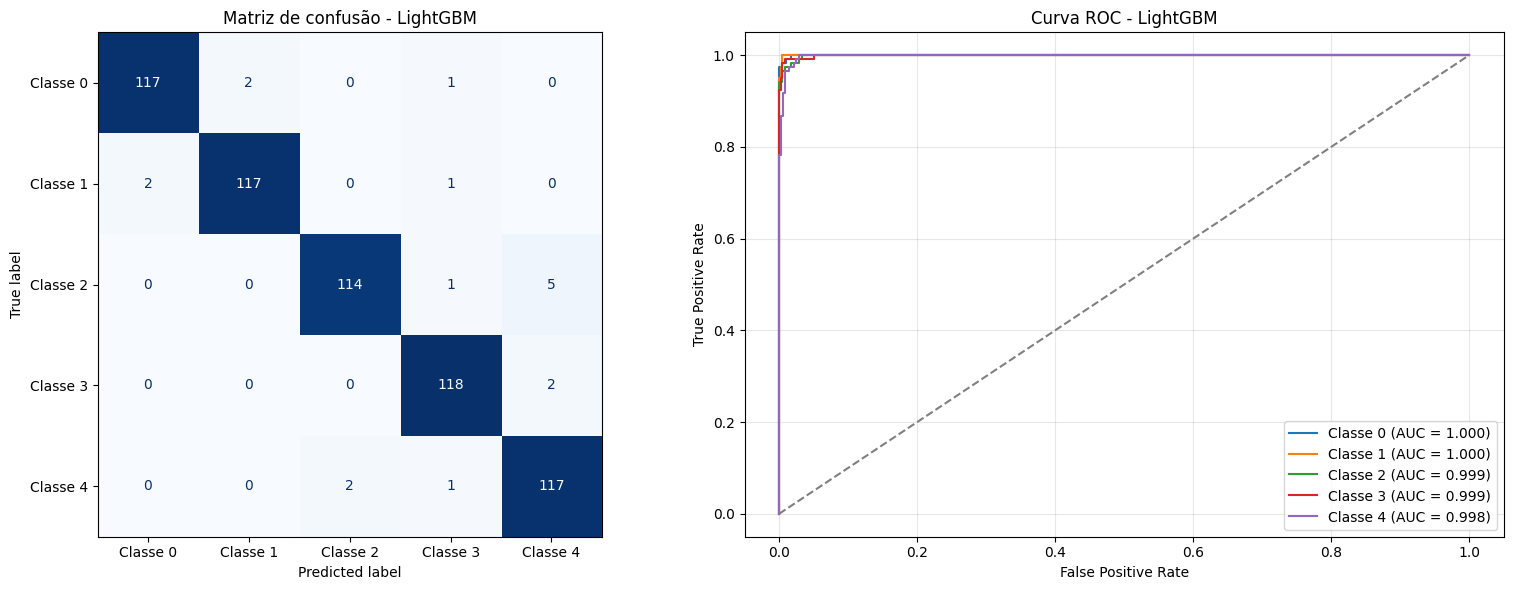

In [15]:
plotar_avaliacao_modelo("LightGBM", y_test, y_pred_lgbm, y_proba_lgbm, "lightgbm")


## 10. Explicabilidade com SHAP

In [16]:
amostras_explicacao_por_grupo = 1
max_amostras_shap_global = 200

metadados_test_explicacao = metadados_test.copy()
metadados_test_explicacao["indice_teste_pos"] = np.arange(metadados_test_explicacao.shape[0])
metadados_test_explicacao["classe_real_nome"] = metadados_test_explicacao["classe"].map(mapa_classes)

grupos_explicacao = []
for _, df_grupo in metadados_test_explicacao.groupby(["dataset_operacao", "classe"], sort=True):
    grupos_explicacao.append(
        df_grupo.sample(n=min(amostras_explicacao_por_grupo, len(df_grupo)), random_state=42)
    )

amostras_explicacao_info = (
    pd.concat(grupos_explicacao, ignore_index=True)
    .sort_values(["dataset_operacao", "classe", "indice_teste_pos"])
    .reset_index(drop=True)
)

indices_explicacao = amostras_explicacao_info["indice_teste_pos"].to_numpy()
X_explicacao = X_test.reset_index(drop=True).iloc[indices_explicacao].copy()
y_explicacao = y_test.reset_index(drop=True).iloc[indices_explicacao].copy()
X_shap_global = (
    X_test.reset_index(drop=True)
    .sample(n=min(max_amostras_shap_global, X_test.shape[0]), random_state=42)
    .reset_index(drop=True)
)

resumo_amostras_explicacao = amostras_explicacao_info[
    ["dataset_operacao", "condicao_operacao", "classe", "classe_real_nome", "segmento_id", "tempo_inicial_s", "tempo_final_s"]
].copy()

print(f"Amostras selecionadas para explicação local: {X_explicacao.shape[0]}")
print(f"Amostras usadas para SHAP global: {X_shap_global.shape[0]}")
display(resumo_amostras_explicacao)

Amostras selecionadas para explicação local: 10
Amostras usadas para SHAP global: 200


,dataset_operacao,condicao_operacao,classe,classe_real_nome,segmento_id,tempo_inicial_s,tempo_final_s
0,1500_10,1500 rpm / 10 Nm,0,Normal,178,178.0,179.0
1,1500_10,1500 rpm / 10 Nm,1,Desgaste Superficial,130,130.0,131.0
2,1500_10,1500 rpm / 10 Nm,2,Dente Trincado,0,0.0,1.0
3,1500_10,1500 rpm / 10 Nm,3,Dente Lascado,18,18.0,19.0
4,1500_10,1500 rpm / 10 Nm,4,Dente Ausente,91,91.0,92.0
5,2700_25,2700 rpm / 25 Nm,0,Normal,193,193.0,194.0
6,2700_25,2700 rpm / 25 Nm,1,Desgaste Superficial,53,53.0,54.0
7,2700_25,2700 rpm / 25 Nm,2,Dente Trincado,17,17.0,18.0
8,2700_25,2700 rpm / 25 Nm,3,Dente Lascado,21,21.0,22.0
9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,193,193.0,194.0


In [ ]:
def organizar_shap_multiclasse(shap_values, n_classes):
    if hasattr(shap_values, "values"):
        shap_array = shap_values.values
    else:
        shap_array = shap_values

    if isinstance(shap_array, list):
        return np.stack(shap_array, axis=0)

    shap_array = np.asarray(shap_array)

    if shap_array.ndim == 3 and shap_array.shape[2] == n_classes:
        return np.moveaxis(shap_array, 2, 0)

    if shap_array.ndim == 3 and shap_array.shape[0] == n_classes:
        return shap_array

    raise ValueError(f"Formato de SHAP não suportado: {shap_array.shape}")


def calcular_shap_multiclasse(modelo, X_ref):
    explainer = shap.TreeExplainer(modelo)
    shap_raw = explainer.shap_values(X_ref)
    return organizar_shap_multiclasse(shap_raw, n_classes=len(classes_roc))


def calcular_importancia_global_shap(shap_classes, colunas_features, nome_modelo, top_k=15):
    impacto_medio = np.mean(np.abs(shap_classes), axis=(0, 1))
    tabela = pd.DataFrame({
        "modelo": nome_modelo,
        "feature": list(colunas_features),
        "impacto_medio_absoluto": impacto_medio,
    }).sort_values("impacto_medio_absoluto", ascending=False).reset_index(drop=True)
    tabela["rank"] = np.arange(1, tabela.shape[0] + 1)
    return tabela.head(top_k).copy()


def tabela_shap_local(shap_classes, X_ref, info_ref, y_proba_ref, nome_modelo, top_k=10):
    classes_preditas = np.argmax(y_proba_ref, axis=1)
    probabilidades_preditas = np.max(y_proba_ref, axis=1)
    registros = []

    for i in range(X_ref.shape[0]):
        classe_predita = int(classes_preditas[i])
        valores_shap = shap_classes[classe_predita, i, :]
        ordem = np.argsort(np.abs(valores_shap))[::-1][:top_k]

        for rank, indice_feature in enumerate(ordem, start=1):
            registros.append({
                "modelo": nome_modelo,
                "amostra_explicacao": i,
                "dataset_operacao": info_ref.loc[i, "dataset_operacao"],
                "condicao_operacao": info_ref.loc[i, "condicao_operacao"],
                "classe_real": int(info_ref.loc[i, "classe"]),
                "classe_real_nome": mapa_classes[int(info_ref.loc[i, "classe"])],
                "classe_predita": classe_predita,
                "classe_predita_nome": mapa_classes[classe_predita],
                "probabilidade_predita": float(probabilidades_preditas[i]),
                "segmento_id": int(info_ref.loc[i, "segmento_id"]),
                "tempo_inicial_s": float(info_ref.loc[i, "tempo_inicial_s"]),
                "tempo_final_s": float(info_ref.loc[i, "tempo_final_s"]),
                "rank": rank,
                "feature": X_ref.columns[indice_feature],
                "valor_feature": float(X_ref.iloc[i, indice_feature]),
                "shap_value": float(valores_shap[indice_feature]),
                "impacto_absoluto": float(abs(valores_shap[indice_feature])),
            })

    return pd.DataFrame(registros)


def plotar_importancia_global_shap(tabela_global, nome_modelo):
    top_plot = tabela_global.sort_values("impacto_medio_absoluto", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_plot["feature"], top_plot["impacto_medio_absoluto"], color="tab:blue")
    ax.set_title(f"SHAP global - {nome_modelo}")
    ax.set_xlabel("Mean absolute SHAP value")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    pasta_imagens = IMAGES_DIR
    pasta_imagens.mkdir(exist_ok=True)
    caminho = pasta_imagens / f"shap_global_{nome_modelo.lower()}_multicondicao.png"
    fig.savefig(caminho, dpi=300, bbox_inches="tight")
    print(f"Gráfico salvo em: {caminho}")
    plt.show()


def plotar_shap_local(tabela_local, nome_modelo):
    quantidade_amostras = tabela_local["amostra_explicacao"].nunique()
    fig, axes = plt.subplots(quantidade_amostras, 1, figsize=(14, 3 * quantidade_amostras), sharex=False)
    if quantidade_amostras == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        tabela_amostra = tabela_local[tabela_local["amostra_explicacao"] == i].sort_values("impacto_absoluto", ascending=True)
        cores = ["tab:blue" if valor >= 0 else "tab:orange" for valor in tabela_amostra["shap_value"]]
        ax.barh(tabela_amostra["feature"], tabela_amostra["shap_value"], color=cores)
        linha_info = tabela_amostra.iloc[-1]
        ax.set_title(
            f"Amostra {i} | {linha_info['dataset_operacao']} | Real: {linha_info['classe_real_nome']} | "
            f"Predita: {linha_info['classe_predita_nome']} ({linha_info['probabilidade_predita']:.3f})"
        )
        ax.set_xlabel("Valor SHAP")
        ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()

    pasta_imagens = IMAGES_DIR
    pasta_imagens.mkdir(exist_ok=True)
    caminho = pasta_imagens / f"shap_local_{nome_modelo.lower()}_multicondicao.png"
    fig.savefig(caminho, dpi=300, bbox_inches="tight")
    print(f"Gráfico salvo em: {caminho}")
    plt.show()

: 

Top features SHAP globais - RandomForest


,modelo,feature,impacto_medio_absoluto,rank
0,RandomForest,rms_x,0.045369,1
1,RandomForest,rms_z,0.040763,2
2,RandomForest,rms_y,0.040731,3
3,RandomForest,amp_fm1_h5_x,0.017319,4
4,RandomForest,amp_fm1_h2_y,0.014840,5
5,RandomForest,amp_max_fm1_h5_x,0.014385,6
6,RandomForest,amp_max_fm1_h1_x,0.012584,7
7,RandomForest,amp_max_fm1_h2_y,0.011520,8
8,RandomForest,amp_fm1_h1_x,0.010849,9
9,RandomForest,amp_fm1_h2_z,0.010407,10


Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\shap_global_randomforest_multicondicao.png


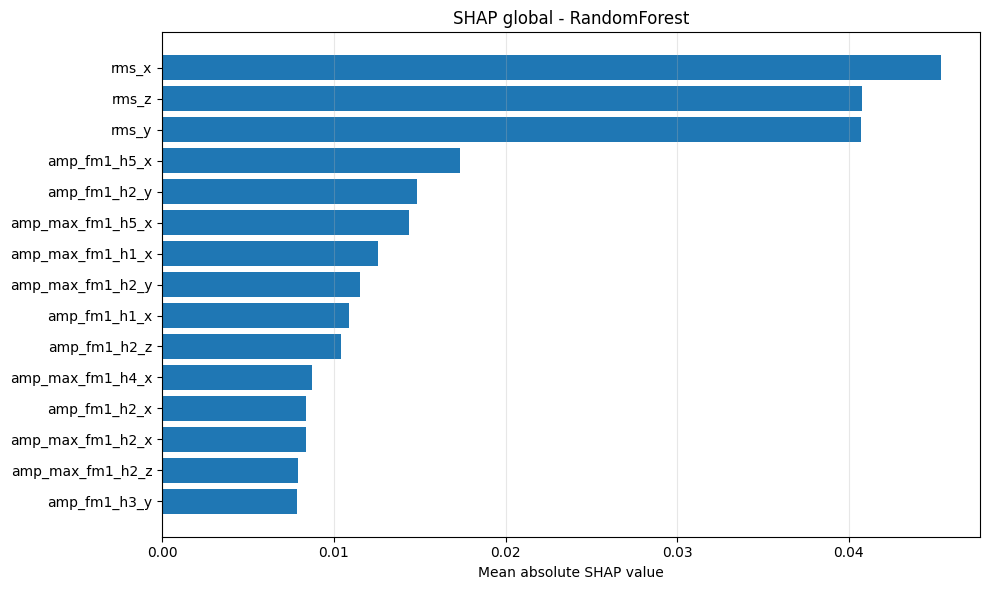

Top features SHAP locais - RandomForest


,modelo,amostra_explicacao,dataset_operacao,condicao_operacao,classe_real,classe_real_nome,classe_predita,classe_predita_nome,probabilidade_predita,segmento_id,tempo_inicial_s,tempo_final_s,rank,feature,valor_feature,shap_value,impacto_absoluto
0,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.850000,178,178.0,179.0,1,rms_x,0.094866,0.102848,0.102848
1,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.850000,178,178.0,179.0,2,rms_z,0.248863,0.074158,0.074158
2,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.850000,178,178.0,179.0,3,amp_fm1_h2_y,0.000707,0.052202,0.052202
3,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.850000,178,178.0,179.0,4,amp_max_fm1_h2_y,0.009560,0.044046,0.044046
4,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.850000,178,178.0,179.0,5,rms_y,0.201725,0.039326,0.039326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,RandomForest,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.866667,193,193.0,194.0,6,amp_fm1_h2_y,0.059998,0.023807,0.023807
96,RandomForest,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.866667,193,193.0,194.0,7,amp_max_fm1_h2_z,0.109390,0.020196,0.020196
97,RandomForest,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.866667,193,193.0,194.0,8,amp_max_fm1_h5_x,0.003971,0.019019,0.019019
98,RandomForest,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.866667,193,193.0,194.0,9,amp_fm_h1_x,0.000772,0.017754,0.017754


Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\shap_local_randomforest_multicondicao.png


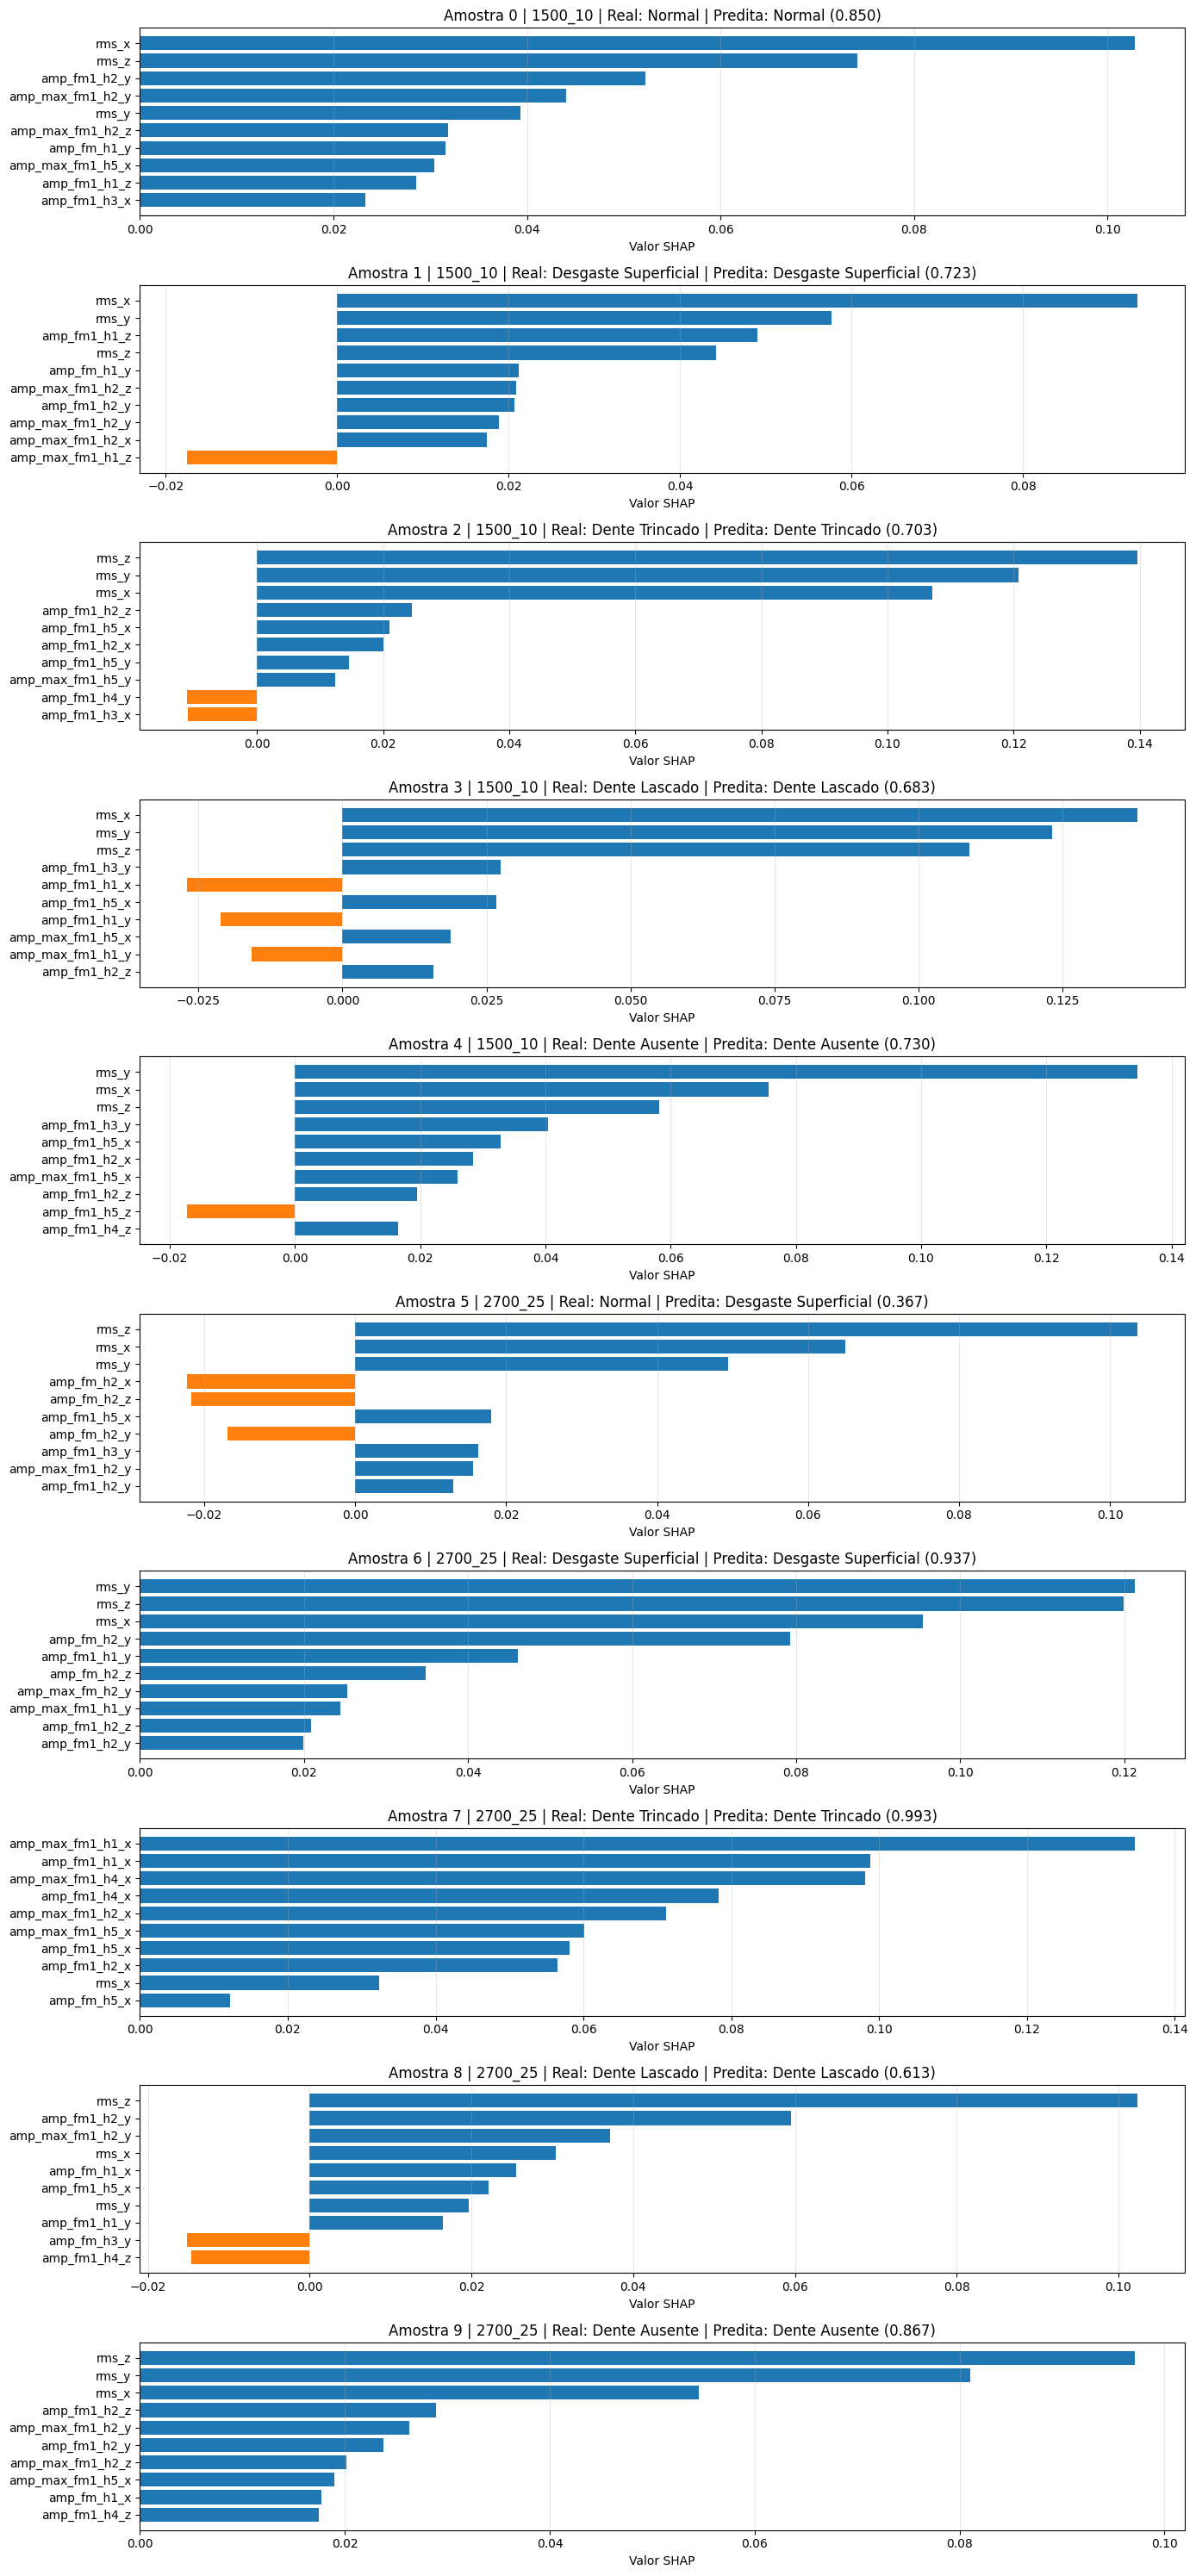

Top features SHAP globais - XGBoost


,modelo,feature,impacto_medio_absoluto,rank
0,XGBoost,rms_x,1.076546,1
1,XGBoost,rms_y,0.887550,2
2,XGBoost,rms_z,0.700632,3
3,XGBoost,amp_fm1_h2_y,0.288713,4
4,XGBoost,amp_fm1_h5_x,0.263878,5
5,XGBoost,amp_fm1_h1_z,0.214506,6
6,XGBoost,amp_fm1_h2_z,0.189520,7
7,XGBoost,amp_fm1_h1_y,0.138212,8
8,XGBoost,amp_fm1_h4_z,0.124697,9
9,XGBoost,amp_fm1_h2_x,0.120262,10


Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\shap_global_xgboost_multicondicao.png


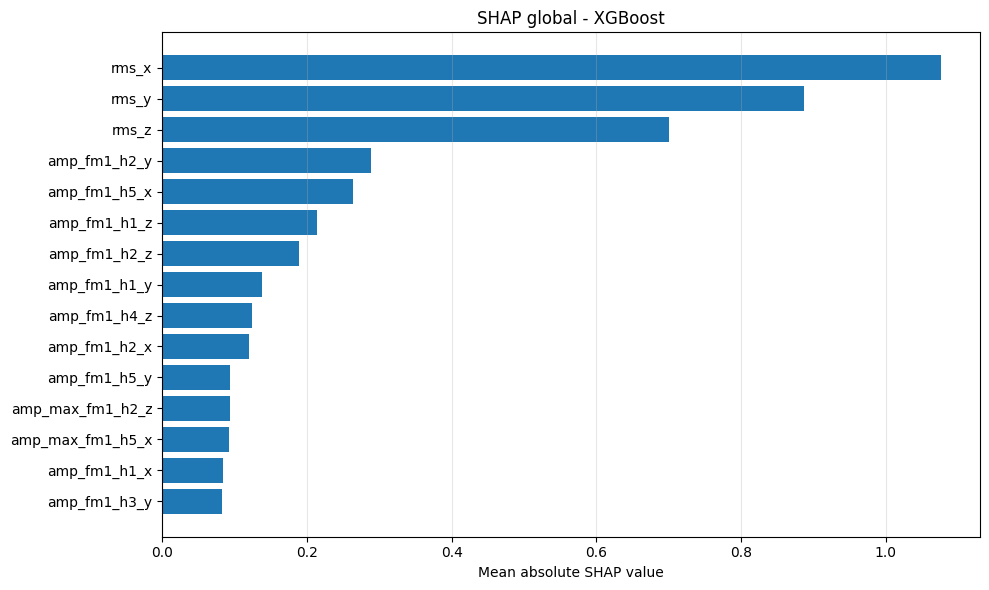

Top features SHAP locais - XGBoost


,modelo,amostra_explicacao,dataset_operacao,condicao_operacao,classe_real,classe_real_nome,classe_predita,classe_predita_nome,probabilidade_predita,segmento_id,tempo_inicial_s,tempo_final_s,rank,feature,valor_feature,shap_value,impacto_absoluto
0,XGBoost,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.996884,178,178.0,179.0,1,rms_x,0.094866,1.587085,1.587085
1,XGBoost,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.996884,178,178.0,179.0,2,amp_fm1_h2_y,0.000707,0.860034,0.860034
2,XGBoost,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.996884,178,178.0,179.0,3,amp_fm_h1_y,0.000043,0.483358,0.483358
3,XGBoost,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.996884,178,178.0,179.0,4,amp_max_fm1_h2_z,0.025671,0.438329,0.438329
4,XGBoost,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.996884,178,178.0,179.0,5,amp_fm1_h5_y,0.001068,0.219053,0.219053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,XGBoost,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.998697,193,193.0,194.0,6,amp_fm1_h2_z,0.050723,0.253774,0.253774
96,XGBoost,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.998697,193,193.0,194.0,7,amp_max_fm1_h4_z,0.014061,0.231555,0.231555
97,XGBoost,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.998697,193,193.0,194.0,8,amp_max_fm_h1_x,0.011785,0.186075,0.186075
98,XGBoost,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.998697,193,193.0,194.0,9,amp_fm1_h2_x,0.003464,-0.145765,0.145765


Gráfico salvo em: C:\Users\MrTatsch\Documents\trabalho_final_residencia\images\shap_local_xgboost_multicondicao.png


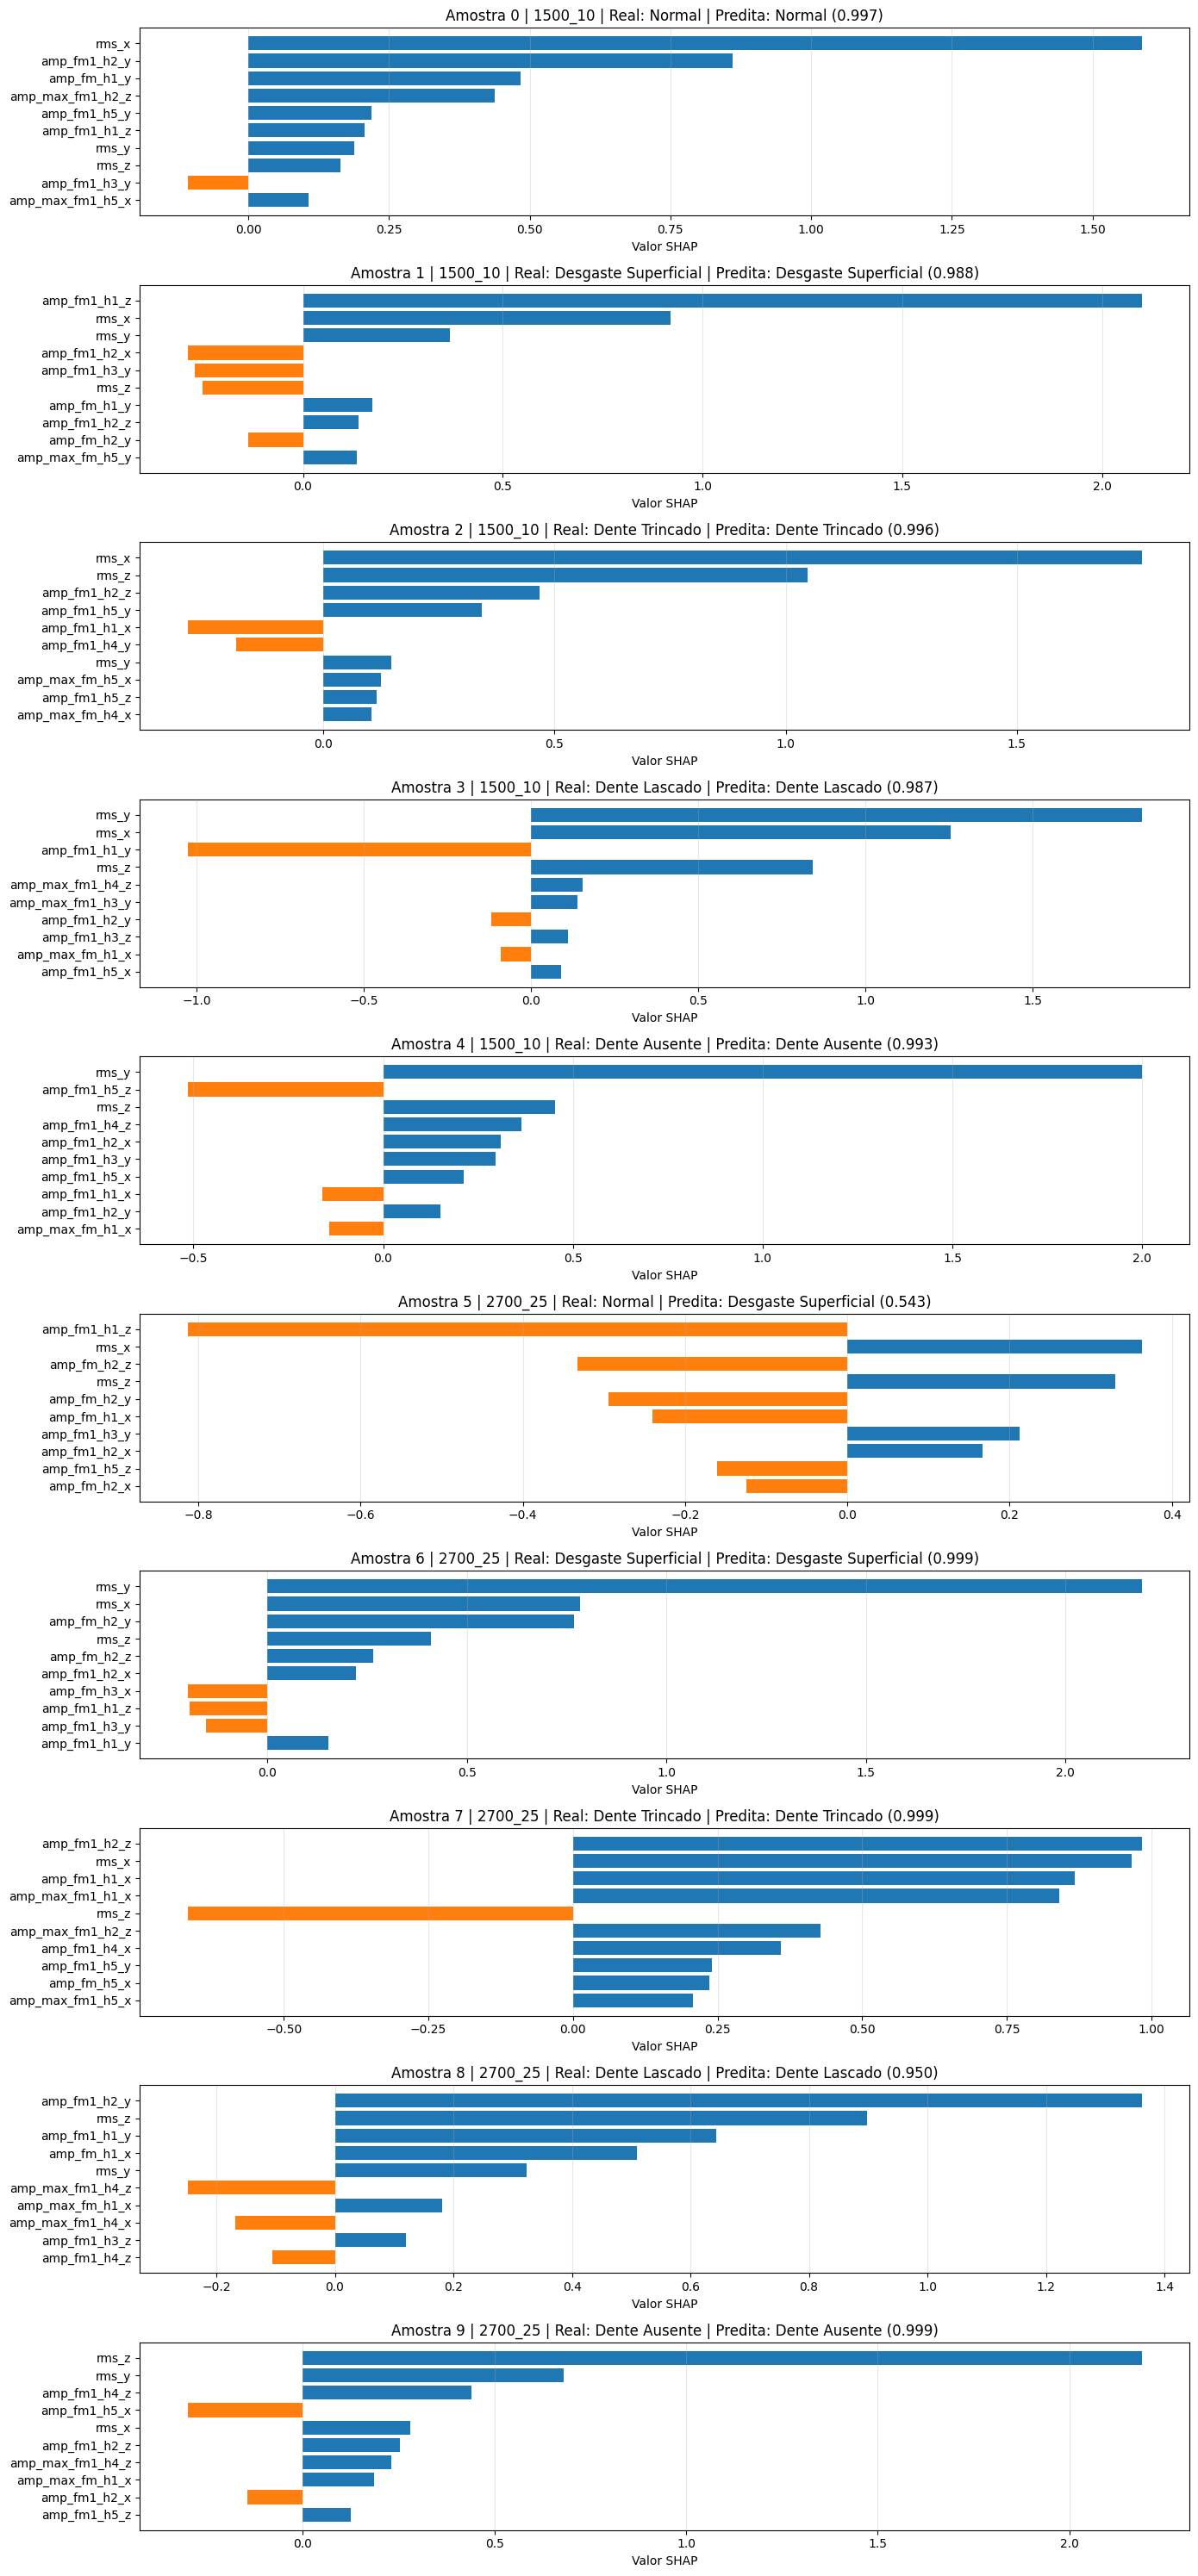

In [ ]:
resultados_shap = {}
tabelas_globais_shap = []
tabelas_locais_shap = []

for nome_modelo, resultado in resultados_modelos.items():
    modelo = resultado["modelo"]
    y_proba_explicacao = modelo.predict_proba(X_explicacao)

    shap_classes_global = calcular_shap_multiclasse(modelo, X_shap_global)
    tabela_global = calcular_importancia_global_shap(
        shap_classes_global,
        X_shap_global.columns,
        nome_modelo,
        top_k=15,
    )

    shap_classes_local = calcular_shap_multiclasse(modelo, X_explicacao)
    tabela_local = tabela_shap_local(
        shap_classes_local,
        X_explicacao,
        amostras_explicacao_info.reset_index(drop=True),
        y_proba_explicacao,
        nome_modelo,
        top_k=10,
    )

    resultados_shap[nome_modelo] = {
        "global": tabela_global,
        "local": tabela_local,
    }
    tabelas_globais_shap.append(tabela_global)
    tabelas_locais_shap.append(tabela_local)

    print(f"Top features SHAP globais - {nome_modelo}")
    display(tabela_global)
    plotar_importancia_global_shap(tabela_global, nome_modelo)

    print(f"Top features SHAP locais - {nome_modelo}")
    display(tabela_local)
    plotar_shap_local(tabela_local, nome_modelo)

comparacao_shap_global = pd.concat(tabelas_globais_shap, ignore_index=True)
comparacao_shap_local = pd.concat(tabelas_locais_shap, ignore_index=True)

In [ ]:
display(comparacao_shap_global)
display(comparacao_shap_local)

,modelo,feature,impacto_medio_absoluto,rank
0,RandomForest,amp_fm1_h5_x,0.039677,1
1,RandomForest,amp_fm1_h1_y,0.027016,2
2,RandomForest,amp_fm1_h2_z,0.024990,3
3,RandomForest,amp_fm1_h2_y,0.024853,4
4,RandomForest,amp_fm1_h1_z,0.023673,5
5,RandomForest,amp_fm1_h1_x,0.022715,6
6,RandomForest,amp_fm1_h2_x,0.022519,7
7,RandomForest,amp_fm1_h3_y,0.021867,8
8,RandomForest,amp_fm1_h3_x,0.019607,9
9,RandomForest,amp_fm1_h4_x,0.013835,10


,modelo,amostra_explicacao,dataset_operacao,condicao_operacao,classe_real,classe_real_nome,classe_predita,classe_predita_nome,probabilidade_predita,segmento_id,tempo_inicial_s,tempo_final_s,rank,feature,valor_feature,shap_value,impacto_absoluto
0,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.523333,178,178.0,179.0,1,amp_fm1_h1_z,0.013491,0.099553,0.099553
1,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.523333,178,178.0,179.0,2,amp_fm1_h2_y,0.002016,0.069646,0.069646
2,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.523333,178,178.0,179.0,3,amp_fm1_h5_x,0.000165,-0.063863,0.063863
3,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.523333,178,178.0,179.0,4,amp_fm1_h3_x,0.000230,0.058665,0.058665
4,RandomForest,0,1500_10,1500 rpm / 10 Nm,0,Normal,0,Normal,0.523333,178,178.0,179.0,5,amp_fm1_h2_z,0.004132,0.049827,0.049827
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,LightGBM,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.993618,193,193.0,194.0,6,amp_fm_h3_y,0.001535,0.932789,0.932789
396,LightGBM,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.993618,193,193.0,194.0,7,amp_fm1_h3_y,0.002874,0.551830,0.551830
397,LightGBM,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.993618,193,193.0,194.0,8,amp_fm1_h5_z,0.002232,0.515124,0.515124
398,LightGBM,9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,4,Dente Ausente,0.993618,193,193.0,194.0,9,amp_fm1_h1_x,0.120349,0.434616,0.434616


## 11. Geração de Prompt para LLM Local

In [ ]:
import re


def formatar_valor_feature(valor_feature):
    valor = float(valor_feature)
    if np.isnan(valor):
        return "nan"
    return f"{valor:.6f}"


def descrever_feature_prompt_local(feature, valor_feature, shap_value):
    contribuicao = "contribuiu positivamente para a classe predita" if shap_value >= 0 else "contribuiu negativamente para a classe predita"
    valor_txt = formatar_valor_feature(valor_feature)

    match_amp_max_fm2 = re.match(r"amp_max_fm_h(\d+)_([xyz])", feature)
    if match_amp_max_fm2:
        ordem, eixo = match_amp_max_fm2.groups()
        return f"Eixo {eixo.upper()}: amplitude máxima observada = {valor_txt} na banda da {ordem}ª harmônica da frequência de engrenamento do 2º estágio; essa variável {contribuicao}."

    match_energy_fm2 = re.match(r"amp_fm_h(\d+)_([xyz])", feature)
    if match_energy_fm2:
        ordem, eixo = match_energy_fm2.groups()
        return f"Eixo {eixo.upper()}: energia observada = {valor_txt} na banda da {ordem}ª harmônica da frequência de engrenamento do 2º estágio; essa variável {contribuicao}."

    match_amp_max_fm1 = re.match(r"amp_max_fm1_h(\d+)_([xyz])", feature)
    if match_amp_max_fm1:
        ordem, eixo = match_amp_max_fm1.groups()
        return f"Eixo {eixo.upper()}: amplitude máxima observada = {valor_txt} na banda da {ordem}ª harmônica da frequência de engrenamento do 1º estágio; essa variável {contribuicao}."

    match_energy_fm1 = re.match(r"amp_fm1_h(\d+)_([xyz])", feature)
    if match_energy_fm1:
        ordem, eixo = match_energy_fm1.groups()
        return f"Eixo {eixo.upper()}: energia observada = {valor_txt} na banda da {ordem}ª harmônica da frequência de engrenamento do 1º estágio; essa variável {contribuicao}."

    match_rms = re.match(r"rms_([xyz])", feature)
    if match_rms:
        eixo = match_rms.group(1)
        return f"Eixo {eixo.upper()}: RMS observado = {valor_txt}; essa variável {contribuicao}."

    match_fm2 = re.match(r"fm_real_([xyz])", feature)
    if match_fm2:
        eixo = match_fm2.group(1)
        return f"Eixo {eixo.upper()}: frequência real de engrenamento do 2º estágio observada = {valor_txt} Hz; essa variável {contribuicao}."

    match_fm1 = re.match(r"fm1_real_([xyz])", feature)
    if match_fm1:
        eixo = match_fm1.group(1)
        return f"Eixo {eixo.upper()}: frequência real de engrenamento do 1º estágio observada = {valor_txt} Hz; essa variável {contribuicao}."

    return f"{feature}: valor observado = {valor_txt}; essa variável {contribuicao}."


def obter_tabela_shap_fonte(nome_modelo):
    if nome_modelo not in resultados_shap:
        raise ValueError(f"Fonte SHAP inválida: {nome_modelo}")
    return resultados_shap[nome_modelo]["local"].copy()


def montar_evidencias_llm(tabela_local, amostra_explicacao, max_evidencias=5):
    tabela_amostra = (
        tabela_local[tabela_local["amostra_explicacao"] == amostra_explicacao]
        .sort_values("impacto_absoluto", ascending=False)
        .head(max_evidencias)
        .copy()
    )
    evidencias = []
    for i, row in enumerate(tabela_amostra.itertuples(index=False), start=1):
        evidencias.append(f"{i}. {descrever_feature_prompt_local(row.feature, row.valor_feature, row.shap_value)}")
    return tabela_amostra, "\n".join(evidencias)


system_prompt_qwen_local = """Você é um especialista em análise de vibração aplicada à manutenção preditiva de redutores planetários.

Tarefa:
Gerar uma explicação técnica curta para uma classificação de falha com base somente nas evidências fornecidas.

Regras:
- Use apenas as informações recebidas.
- Não invente frequências, componentes, causas ou sintomas não citados.
- Não trate uma variável como alta, baixa, elevada, reduzida ou anormal sem referência explícita no prompt.
- Interprete as evidências como variáveis que contribuíram para a classe predita, usando os valores observados e o contexto mecânico disponível.
- Não mencione SHAP, modelo, IA, prompt ou explicabilidade.
- Não forneça ações recomendadas.
- Seja técnico, direto e conciso.
- Se a evidência for moderada, use linguagem cautelosa, como "compatível com" ou "sugere".
- Responda exatamente com estas duas seções:
Interpretação Vibracional:
Interpretação Mecânica:"""

In [ ]:
fonte_shap_llm_local = "LightGBM"  # RandomForest, XGBoost, CatBoost ou LightGBM
amostra_explicacao_llm_local = 0
max_evidencias_llm_local = 5

tabela_shap_fonte_llm_local = obter_tabela_shap_fonte(fonte_shap_llm_local)
tabela_llm_amostra, evidencias_traduzidas_llm = montar_evidencias_llm(
    tabela_shap_fonte_llm_local,
    amostra_explicacao_llm_local,
    max_evidencias=max_evidencias_llm_local,
)

if tabela_llm_amostra.empty:
    raise ValueError("Nenhuma evidência SHAP encontrada para a amostra selecionada.")

linha_ref_llm = tabela_llm_amostra.iloc[0]

user_prompt_qwen_local = f"""Equipamento: redutor planetário de 2 estágios.
Componente monitorado: engrenagem solar do 2º estágio.
Condição operacional: {linha_ref_llm['condicao_operacao']}.

Classes possíveis:
0 = Normal
1 = Desgaste Superficial
2 = Dente Trincado
3 = Dente Lascado
4 = Dente Ausente

Legenda física das variáveis:
- RMS: nível global de vibração do segmento.
- Amplitude máxima na banda: maior amplitude espectral dentro da banda analisada.
- Energia na banda: soma da amplitude ao quadrado dentro da banda analisada.
- Fm: frequência de engrenamento.
- Harmônica de Fm: múltiplo inteiro da frequência de engrenamento.
- Banda de ressonância: faixa de alta frequência associada à excitação estrutural.
- Modulação lateral: variação espectral ao redor da frequência de engrenamento, compatível com defeitos distribuídos ou localizados.

Classificação predita: {linha_ref_llm['classe_predita_nome']}.
Probabilidade da classe predita: {linha_ref_llm['probabilidade_predita']:.3f}.

Evidências principais:
{evidencias_traduzidas_llm}

Escreva a resposta final."""

prompt_llm_local = {
    "fonte_shap": fonte_shap_llm_local,
    "amostra_explicacao": int(amostra_explicacao_llm_local),
    "system_prompt": system_prompt_qwen_local,
    "user_prompt": user_prompt_qwen_local,
}

display(tabela_llm_amostra[[
    "dataset_operacao",
    "classe_real_nome",
    "classe_predita_nome",
    "probabilidade_predita",
    "feature",
    "shap_value",
    "impacto_absoluto",
]])

print("SYSTEM PROMPT:\n")
print(system_prompt_qwen_local)
print("\nUSER PROMPT:\n")
print(user_prompt_qwen_local)

,dataset_operacao,classe_real_nome,classe_predita_nome,probabilidade_predita,feature,shap_value,impacto_absoluto
0,1500_10,Normal,Normal,0.999993,rms_x,4.367882,4.367882
1,1500_10,Normal,Normal,0.999993,amp_fm1_h2_y,2.138074,2.138074
2,1500_10,Normal,Normal,0.999993,amp_max_fm1_h2_z,1.763425,1.763425
3,1500_10,Normal,Normal,0.999993,amp_fm_h1_y,1.175567,1.175567
4,1500_10,Normal,Normal,0.999993,rms_y,0.751049,0.751049


SYSTEM PROMPT:

Você é um especialista em análise de vibração aplicada à manutenção preditiva de redutores planetários.

Tarefa:
Gerar uma explicação técnica curta para uma classificação de falha com base somente nas evidências fornecidas.

Regras:
- Use apenas as informações recebidas.
- Não invente frequências, componentes, causas ou sintomas não citados.
- Não trate uma variável como alta, baixa, elevada, reduzida ou anormal sem referência explícita no prompt.
- Interprete as evidências como variáveis que contribuíram para a classe predita, usando os valores observados e o contexto mecânico disponível.
- Não mencione SHAP, modelo, IA, prompt ou explicabilidade.
- Não forneça ações recomendadas.
- Seja técnico, direto e conciso.
- Se a evidência for moderada, use linguagem cautelosa, como "compatível com" ou "sugere".
- Responda exatamente com estas duas seções:
Interpretação Vibracional:
Interpretação Mecânica:

USER PROMPT:

Equipamento: redutor planetário de 2 estágios.
Componente